In [1]:
import sys
from os import path, getcwd
import pathlib

# where everything is stored (data and code)
ROOT = pathlib.Path(getcwd()).parent.absolute()
# code paths
sys.path.append(path.join(ROOT, 'src/models'))
sys.path.append(path.join(ROOT, 'src/exp'))
sys.path.append(path.join(ROOT, 'src/common'))

from scipy.stats import norm, vonmises, special_ortho_group, multivariate_normal, uniform, chi2, wasserstein_distance
from scipy.special import erf, loggamma
from math import sqrt
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import figure
import numpy as np
import torch
from collections.abc import Iterable
from scipy.stats import uniform
import warnings

%reload_ext autoreload
%autoreload 2

from precomputation.initialization import *
from misc.common_functions import *
from inflation.jupyter_helper import *

warnings.simplefilter(action='ignore', category=FutureWarning)

from master.data.line_data import LineData
from master.data.gauss_data import GaussData
from master.data.smoothstep_data import SmoothstepData


In [35]:
TITLE_SIZE = 15
LEGEND_SIZE = 14
AXIS_TITLE_SIZE = 18


mises_params_05 = dict(mises_kappa=0.5, sphere_radius=0, dimension=36, data_mode='sampled')
mises_params_4 = dict(mises_kappa=6, sphere_radius=0, dimension=36, data_mode='sampled')
norm_params = {'loc': 0, 'scale': 1}
uniform_params =  dict(line_length=1, dimension=36, data_mode='sampled')
student_params = {'df': 4}
smoothstep_params = dict(dimension=36, start=-5, end=5, offset=1, Range=10, growth=0.5, data_mode='sampled')
%matplotlib inline

Gradient for volume change

In [27]:
sigma = 1e-4
std_dev = np.sqrt(sigma)

v_init = 1.01#1/std_dev
log_v_init = np.log(v_init)

log_v = log_v_init
v = v_init
batch_size = 10000
batch_per_epoch = 32

delta = 1e-4
delta = 1
for i in range(10000):
    if i % 1000 == 0:
        print(f'v: {v:.4f}, exp log v: {np.exp(log_v)}, should be: {1/std_dev}, delta: {delta:.2e}')
         
    x = norm.rvs(scale=std_dev, size=batch_size)
    
    grad = 1/v - v * np.mean(x**2)
    v -= delta * grad
    v = np.abs(v)
    
    log_grad = 1 - np.exp(log_v**2) * np.mean(x**2)
    log_v -= delta * log_grad
    
    if i % batch_per_epoch == 0:
        delta = delta * 0.99
         

v: 1.0100, exp log v: 1.01, should be: 100.0, delta: 1.00e+00


<ipython-input-27-4ab3b0b10b0c>:24: RuntimeWarning: overflow encountered in double_scalars
  log_grad = 1 - np.exp(log_v**2) * np.mean(x**2)


v: 32.3310, exp log v: inf, should be: 100.0, delta: 7.25e-01
v: 1500.0488, exp log v: inf, should be: 100.0, delta: 5.31e-01
v: 1569.6878, exp log v: inf, should be: 100.0, delta: 3.89e-01
v: 1622.6384, exp log v: inf, should be: 100.0, delta: 2.85e-01
v: 1662.4512, exp log v: inf, should be: 100.0, delta: 2.06e-01
v: 1692.1443, exp log v: inf, should be: 100.0, delta: 1.51e-01
v: 1714.1876, exp log v: inf, should be: 100.0, delta: 1.11e-01
v: 1730.4500, exp log v: inf, should be: 100.0, delta: 8.11e-02
v: 1742.4290, exp log v: inf, should be: 100.0, delta: 5.88e-02


arg min log score exp 101.192
arg min score 100.100


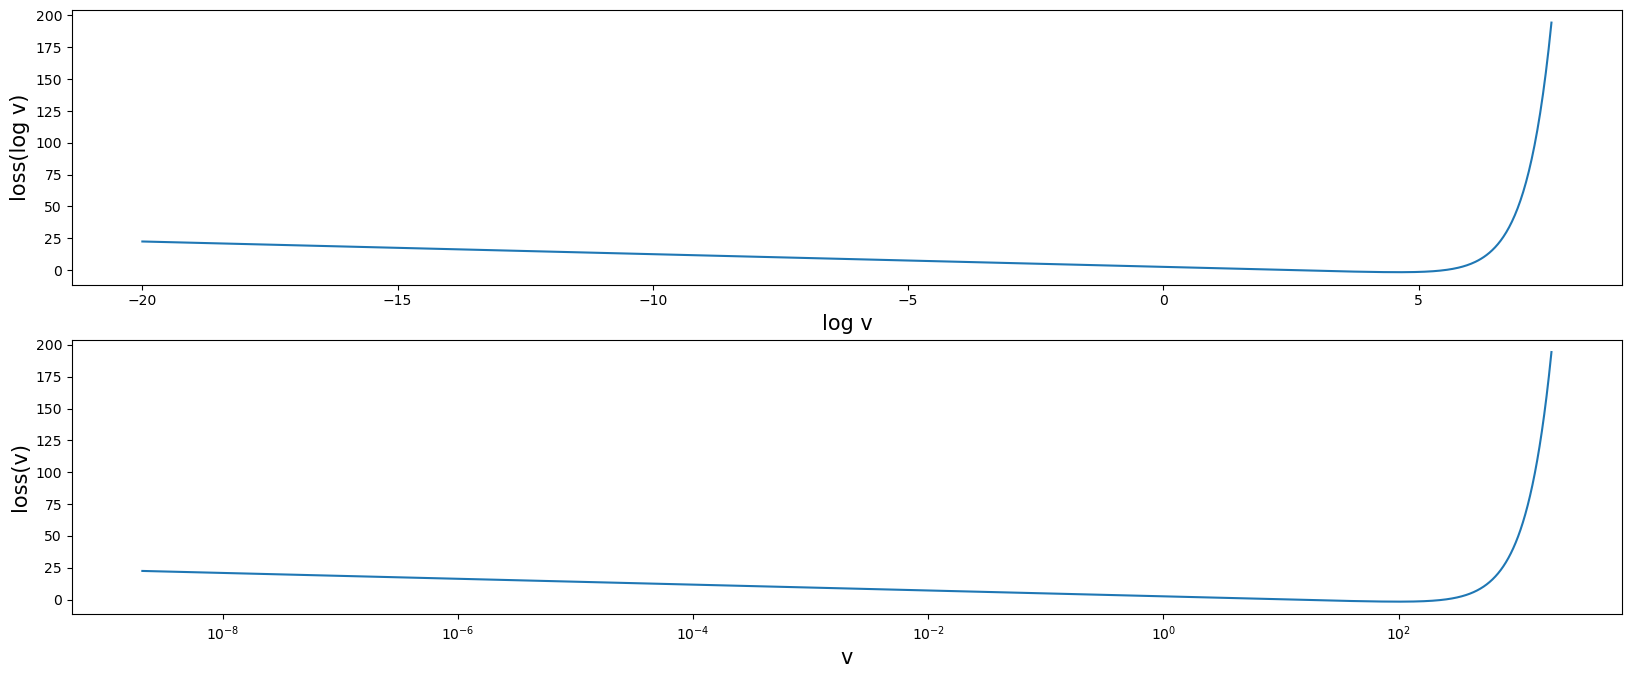

In [115]:
%matplotlib inline
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(20, 8), squeeze=True, dpi=100)

min_log_lim = -20
max_log_lim = np.log(2000)
log_v = np.linspace(min_log_lim, max_log_lim, 1000)
v = np.linspace(np.exp(min_log_lim), np.exp(max_log_lim), 1000)

x = norm.rvs(scale=std_dev, size=2000)
x = x.reshape(len(x), 1)

log_v = log_v.reshape(1, len(log_v))
v = v.reshape(1, len(v))

log_score = -(log_v - 1/2 * (np.exp(log_v) * x)**2 - np.sqrt(2*np.pi)).mean(0)
score = -(np.log(v) - 1/2 * (v * x)**2 - np.sqrt(2*np.pi)).mean(0)

log_v = log_v.flatten()
v = v.flatten()

axs[0].plot(log_v, log_score, label='')

axs[0].set_xlabel('log v', size=15)
axs[0].set_ylabel('loss(log v)', size=15)

axs[1].plot(v, score, label='')

axs[1].set_xlabel('v', size=15)
axs[1].set_ylabel('loss(v)', size=15)
axs[1].set_xscale('log')

print(f'arg min log score exp {np.exp(log_v[np.argmin(log_score)]):.3f}')
print(f'arg min score {v[np.argmin(score)]:.3f}')

-----------

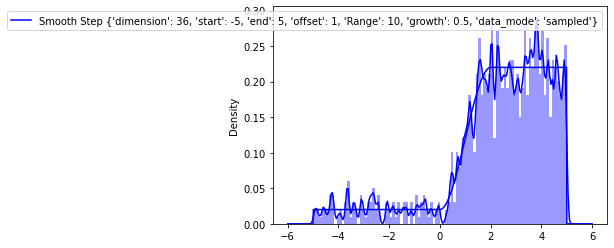

In [8]:
%matplotlib inline
def plot_ss(params, clr):    
    #, sample_seed=10
    step_data = SmoothstepData(size=1000, **params)
    samples = step_data.data[NONE_EMBEDDED_DATA][:, 0]
    
    sns.distplot(samples, color=clr, hist=True, kde=True, norm_hist=True, kde_kws={'bw_adjust': 0.1}, bins=100)

    x = np.linspace(-6, 6, 1000)
    pds = step_data.pdf_on_manifold(x)

    plt.plot(x, pds, '-', label='Smooth Step ' + str(params), color=clr,)

plot_ss(smoothstep_params, 'b')
#plot_ss(dict(dimension=36, start=-1, end=1, offset=1, Range=2, growth=2, data_mode='sampled'), 'g')
#plot_ss(dict(dimension=36, start=-15, end=15, offset=1, Range=2, growth=2, data_mode='sampled'), 'g')
plt.legend()
_=_

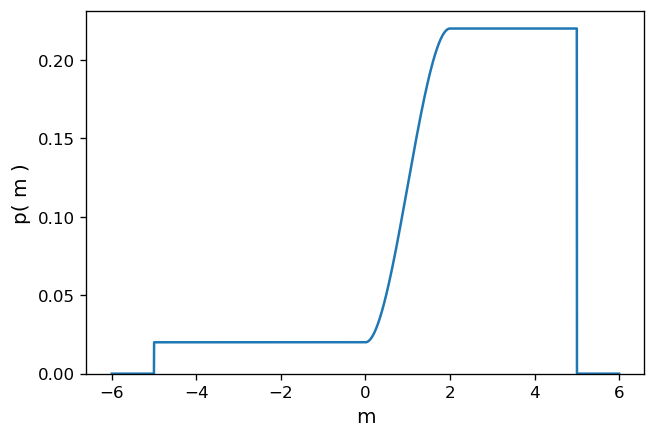

In [24]:
%matplotlib inline
def plot_pure_ss(params):    
    #, sample_seed=10
    step_data = SmoothstepData(size=1000, **params)
    
    x = np.linspace(-6, 6, 3000)
    pds = step_data.pdf_on_manifold(x)

    plt.plot(x, pds, '-') # , label='Smooth Step'
    plt.xlabel('m', size=12)
    plt.ylabel('p( m )', size=12)
    plt.ylim(bottom=0)

fig, axs = plt.subplots(nrows=1, ncols=1, squeeze=True, dpi=120)
plot_pure_ss(smoothstep_params)
#plot_ss(dict(dimension=36, start=-1, end=1, offset=1, Range=2, growth=2, data_mode='sampled'), 'g')
#plot_ss(dict(dimension=36, start=-15, end=15, offset=1, Range=2, growth=2, data_mode='sampled'), 'g')
#plt.legend()
_=_

In [19]:
from scipy.stats import special_ortho_group
x = special_ortho_group.rvs(3)
np.dot(x.T, x)

array([[ 1.00000000e+00, -1.11022302e-16, -3.33066907e-16],
       [-1.11022302e-16,  1.00000000e+00, -8.32667268e-17],
       [-3.33066907e-16, -8.32667268e-17,  1.00000000e+00]])

(1000, 100)
(100, 100)
(1000, 100)


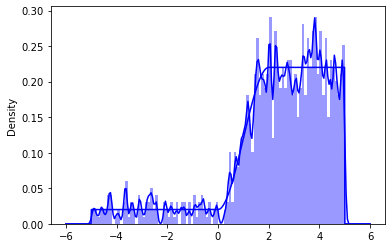

In [22]:
def plot_ss_back_rotation(params, clr):
    params = dict(params)
    params['dimension'] = 100
    #, sample_seed=10
    step_data = SmoothstepData(size=1000, **params)
    embedded_data = step_data.data[EMBEDDED_DATA].numpy()
    embedded_data = embedded_data.reshape((len(embedded_data), -1))
    #print(embedded_data.shape)
    #print(step_data.rotation_matrix.shape)
    
    samples = step_data.rotation_matrix.T @ embedded_data.T
    samples = samples.T
    
    #print(samples.shape)
    samples = samples[:, 0]
    #samples = step_data.data[NONE_EMBEDDED_DATA][:, 0]
    
    sns.distplot(samples, color=clr, hist=True, kde=True, norm_hist=True, kde_kws={'bw_adjust': 0.1}, bins=100)

    x = np.linspace(-6, 6, 1000)
    pds = step_data.pdf_on_manifold(x)

    plt.plot(x, pds, '-', label='Smooth Step ' + str(params), color=clr,)

plot_ss_back_rotation(smoothstep_params, 'b')

<AxesSubplot:ylabel='Density'>

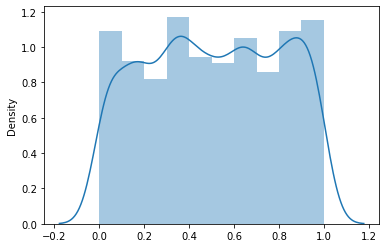

In [54]:
sns.distplot(uniform.rvs(size=1000), hist=True, label=f'Uniform', kde=True, norm_hist=True, kde_kws={'bw_adjust': 0.8})

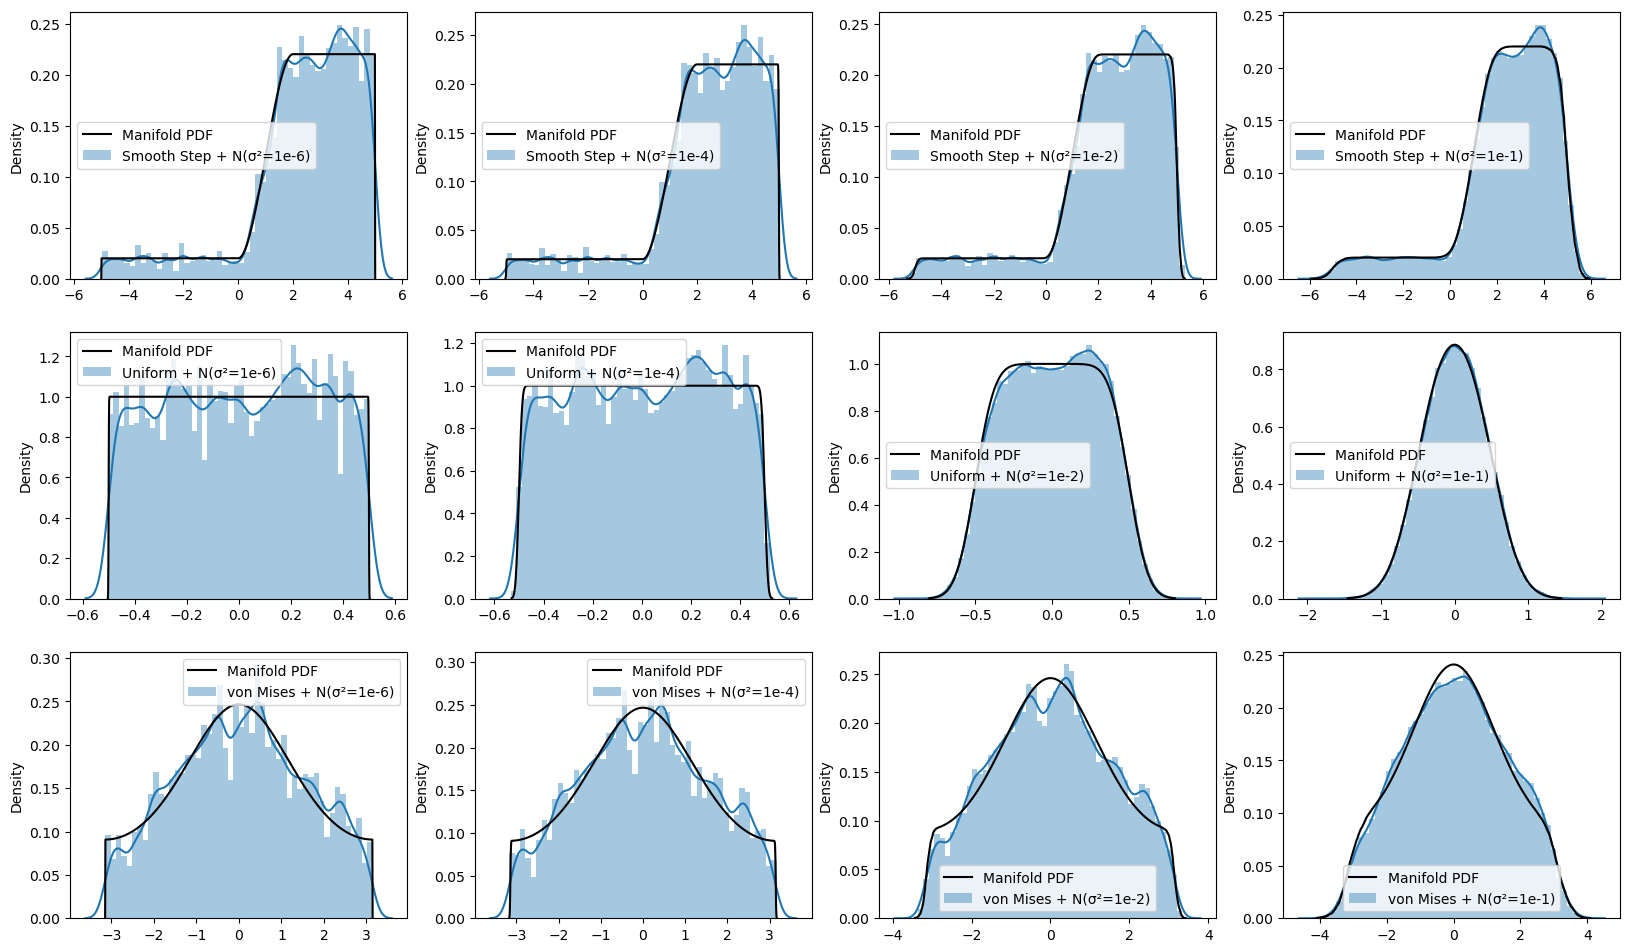

In [34]:
%matplotlib inline
def dis_plotter_ex(data, naming, ax, var):    
    #clr = plt.get_cmap('tab10').colors[nr]
    
    samples = data.data[NONE_EMBEDDED_DATA][:, 0]
    samples = np.repeat(samples, 50)
    
    samples += norm.rvs(scale=np.sqrt(var), size=len(samples))
    
    #samples = data.data[NONE_EMBEDDED_DATA][:, 0]
    sns.distplot(samples, ax=ax, hist=True, label=naming.get_name_with_var(), 
                 kde=True, norm_hist=True, kde_kws={'bw_adjust': 1}, bins=50)
    
    x = np.linspace(*naming._get_inflated_manifold_bounds(sigma_count=3), 1000)
    
    pds = np.exp(naming.log_pdf_on_inflated_manifold(x))
    ax.plot(x, pds, '-', color='k', label='Manifold PDF')
    ax.legend()

def dis_plotter(samples):
    fig, axs = plt.subplots(nrows=3, ncols=4, figsize=(20, 12), dpi=100)
    #axs = axs.flatten()
    
    variances = [1e-6, 1e-4, 1e-2, 1e-1]
    for i, data_type in enumerate(['ss', 'uni', 'mises']):
        assert False, 'consider tangent_noise_scale'
        # data will be generated above
        if data_type == 'ss':
            data = SmoothstepData(size=samples, noise_scale=None, **smoothstep_params)
        elif data_type == 'uni':
            data = LineData(size=samples, noise_scale=None, **uniform_params)
        elif data_type == 'mises':
            data = VonMises(size=samples, noise_scale=None, **mises_params_05)

        for ax, var in zip(axs[i], variances):
            scale = None if var is None else np.sqrt(var)

            if data_type == 'ss':
                naming = SmoothstepData(size=10, noise_scale=scale, **smoothstep_params)
            elif data_type == 'uni':
                naming = LineData(size=10, noise_scale=scale, **uniform_params)
            elif data_type == 'mises':
                naming = VonMises(size=10, noise_scale=scale, **mises_params_05)

            dis_plotter_ex(data, naming, ax, var)
    
dis_plotter(2000)

_=_

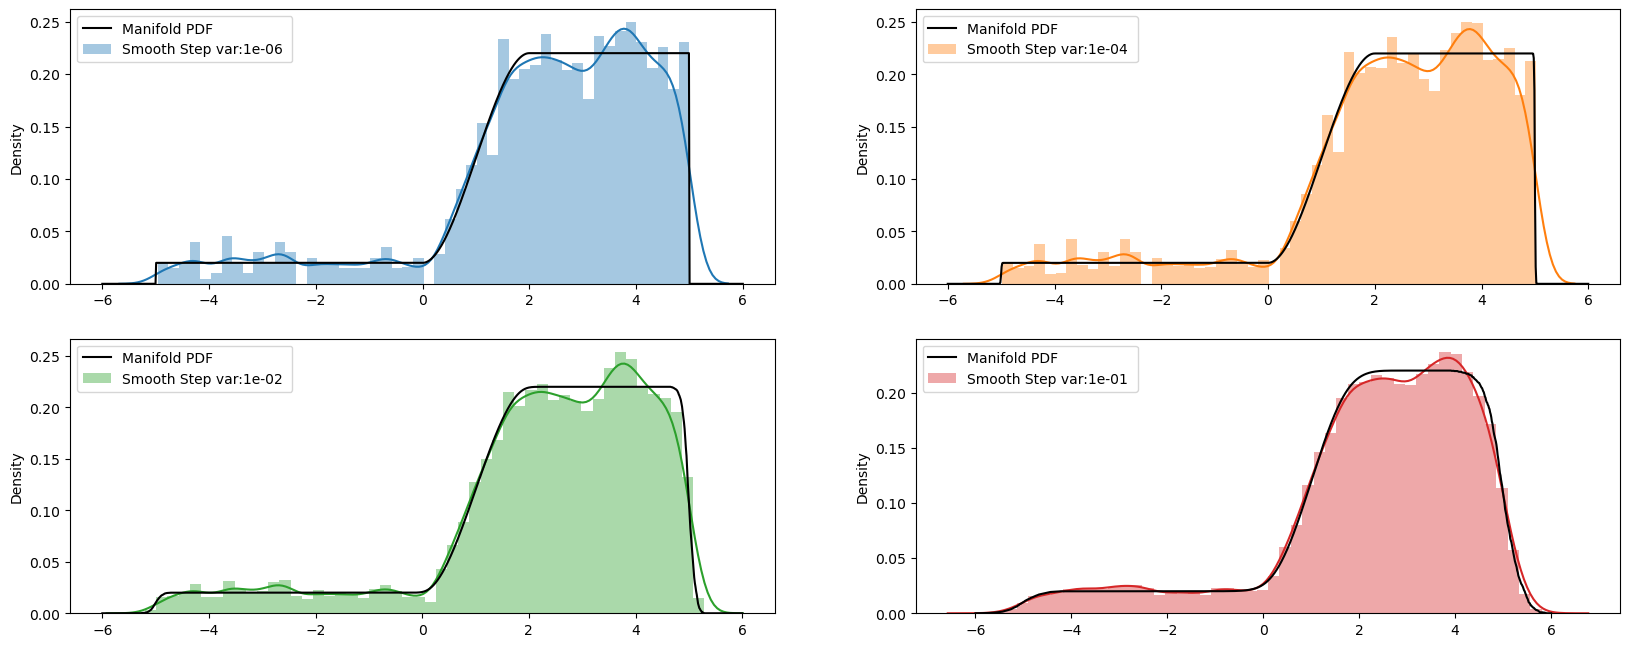

In [7]:
%matplotlib inline
def plot_ss_with_noise(data, axs, nr, var):    
    clr = plt.get_cmap('tab10').colors[nr]
    
    samples = data.data[NONE_EMBEDDED_DATA][:, 0]
    samples = np.repeat(samples, 50)
    
    samples += norm.rvs(scale=np.sqrt(var), size=len(samples))
    
    sns.distplot(samples, ax=axs[nr], hist=True, label=f'Smooth Step var:{var:.0e} ', color=clr, 
                 kde=True, norm_hist=True, kde_kws={'bw_adjust': 1}, bins=100)
    
    x = np.linspace(-6, 6, 1000)
    #pds = data.pdf_on_manifold(x)
    step_data = SmoothstepData(size=10, noise_scale=np.sqrt(var), **smoothstep_params)
    pds = np.exp(step_data.log_pdf_on_inflated_manifold(x))
    axs[nr].plot(x, pds, '-', color='k', label='Manifold PDF')
    axs[nr].legend()

    
def smooth_step_dis_plotter(sample_size):
    fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 8), squeeze=True, dpi=100)
    axs = axs.flatten()

    #plt.suptitle(f'Smooth Step with {sample_size} Samples', fontweight='bold', size=15)
    step_data = SmoothstepData(size=sample_size, noise_scale=None, **smoothstep_params)
    plot_ss_with_noise(step_data, axs, 0, var=1e-6)
    plot_ss_with_noise(step_data, axs, 1, var=1e-4)
    plot_ss_with_noise(step_data, axs, 2, var=1e-2)
    plot_ss_with_noise(step_data, axs, 3, var=1e-1)
smooth_step_dis_plotter(1000)
_=_

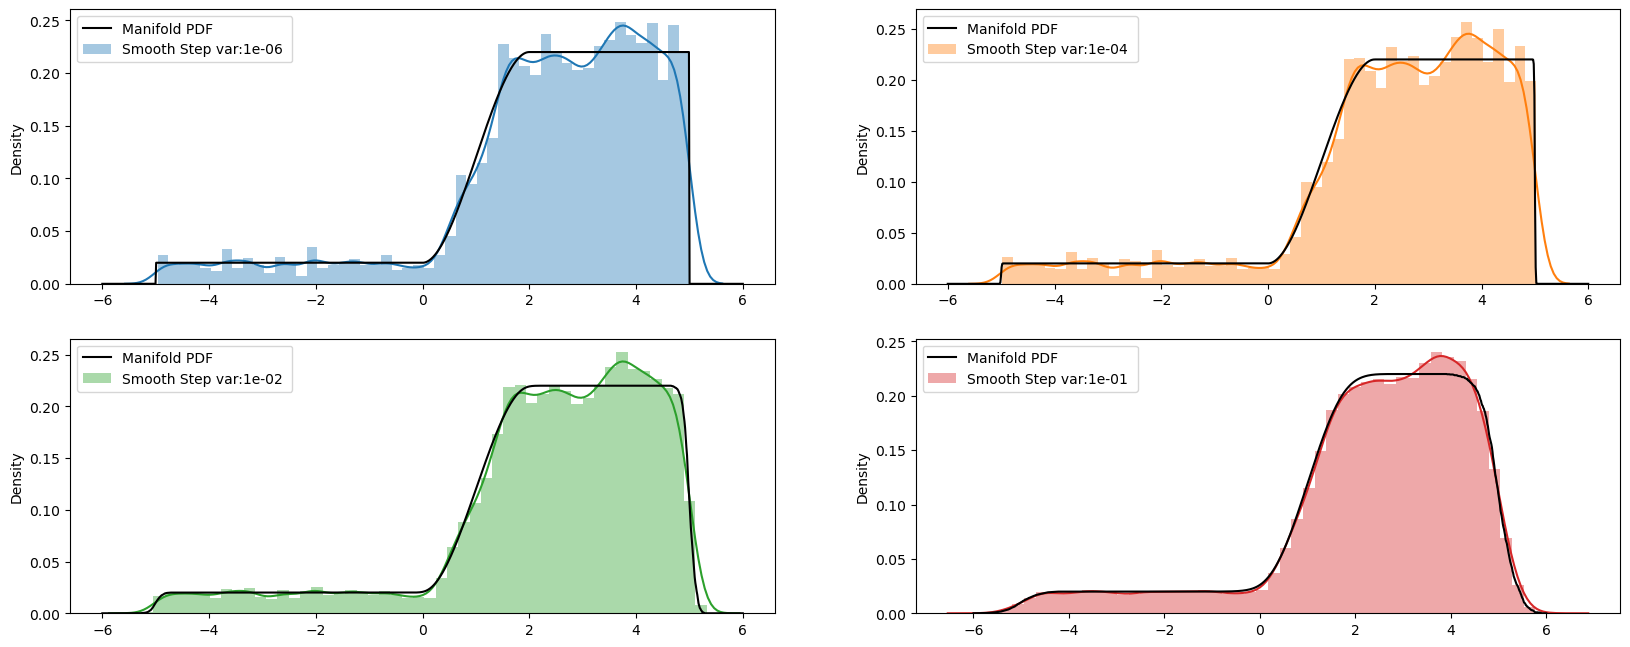

In [8]:
smooth_step_dis_plotter(2000)

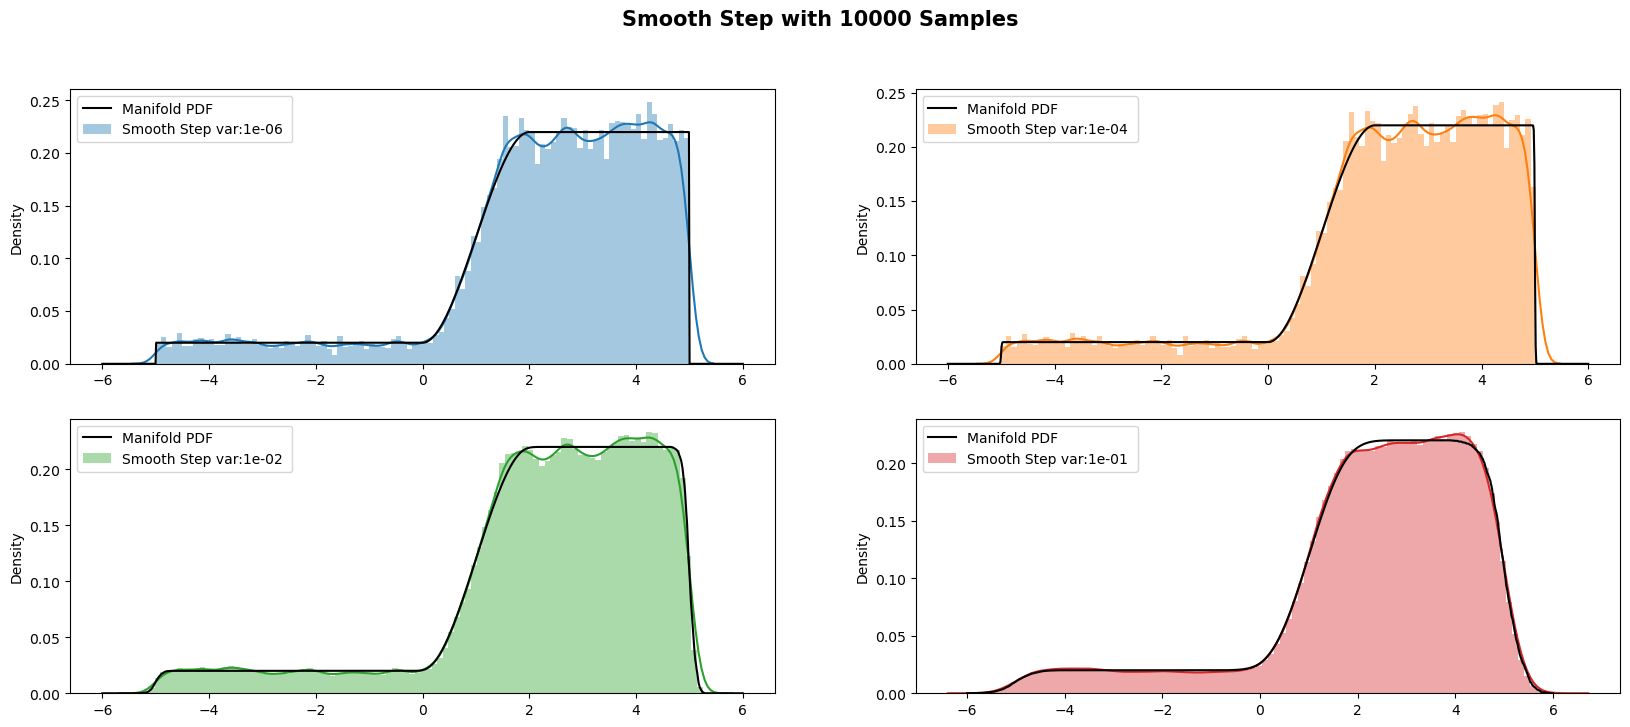

In [24]:
smooth_step_dis_plotter(10000)

-------------

C:\Mega\trunk\master-thesis\src\models\master\data\line_data.py:44: RuntimeWarning: divide by zero encountered in log
  return np.log(pdf_N_plus_Uni(samples, self.var))
C:\Mega\trunk\master-thesis\src\models\master\data\line_data.py:44: RuntimeWarning: divide by zero encountered in log
  return np.log(pdf_N_plus_Uni(samples, self.var))
C:\Mega\trunk\master-thesis\src\models\master\data\line_data.py:44: RuntimeWarning: divide by zero encountered in log
  return np.log(pdf_N_plus_Uni(samples, self.var))


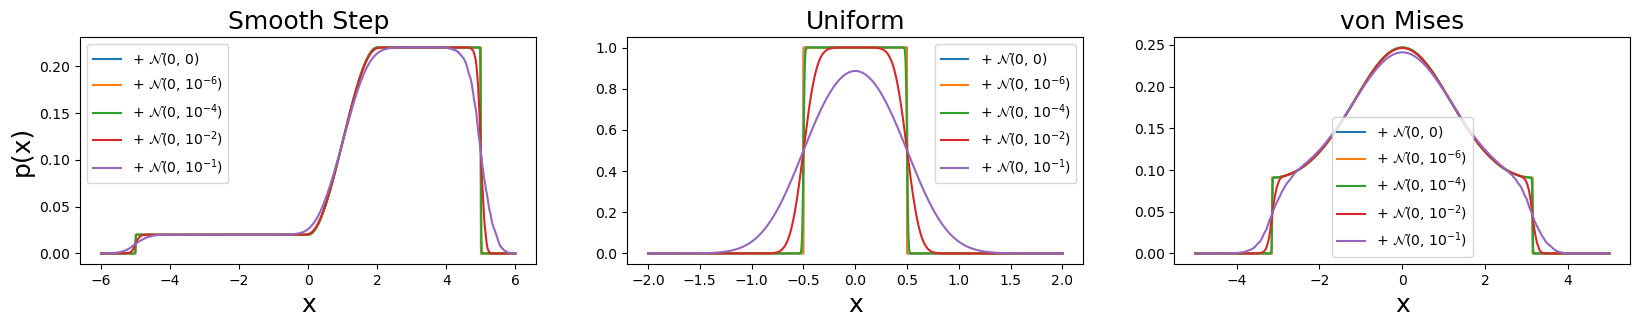

In [36]:
##### %matplotlib inline
def plot_dataset_pdf(data, axs, nr, var, from_to):    
    clr = plt.get_cmap('tab10').colors[nr]

    x = np.linspace(*from_to, 1000)
    pds = np.exp(data.log_pdf_on_inflated_manifold(x))
    
    existing_pds = pds != None
    pds = pds[existing_pds]
    x = x[existing_pds]
    
    axs.plot(x, pds, '-', label='+ ' + data.get_printable_var())
    axs.legend()

    
variances = [None, 1e-6, 1e-4, 1e-2, 1e-1]

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(20, 3), squeeze=True, dpi=100)
axs = axs.flatten()

#plt.suptitle(f'Smooth Step with {sample_size} Samples', fontweight='bold', size=15)

for var in variances:
    scale = None if var is None else np.sqrt(var)
    
    step_data = SmoothstepData(size=10, normal_noise_scale=scale, tangent_noise_scale=scale, **smoothstep_params)
    plot_dataset_pdf(step_data, axs[0], 0, var=var, from_to=[-6, 6])
    
    line_data = LineData(size=10, normal_noise_scale=scale, tangent_noise_scale=scale, **uniform_params)
    plot_dataset_pdf(line_data, axs[1], 0, var=var, from_to=[-2, 2])
    
    sphere_data = VonMises(size=10, normal_noise_scale=scale, tangent_noise_scale=scale, **mises_params_05)
    plot_dataset_pdf(sphere_data, axs[2], 0, var=var, from_to=[-5, 5])

axs[0].set_title('Smooth Step', size=AXIS_TITLE_SIZE)
axs[1].set_title('Uniform', size=AXIS_TITLE_SIZE)
axs[2].set_title('von Mises', size=AXIS_TITLE_SIZE)

for ax in axs:
    ax.set_xlabel('x', size=AXIS_TITLE_SIZE)
axs[0].set_ylabel('p(x)', size=AXIS_TITLE_SIZE)

plt.savefig('E:/datasets.pdf', format='pdf', bbox_inches='tight')
_=_

In [7]:
smoothstep_params

{'dimension': 36,
 'start': -5,
 'end': 5,
 'offset': 1,
 'Range': 10,
 'growth': 0.5,
 'data_mode': 'sampled'}

-----------------

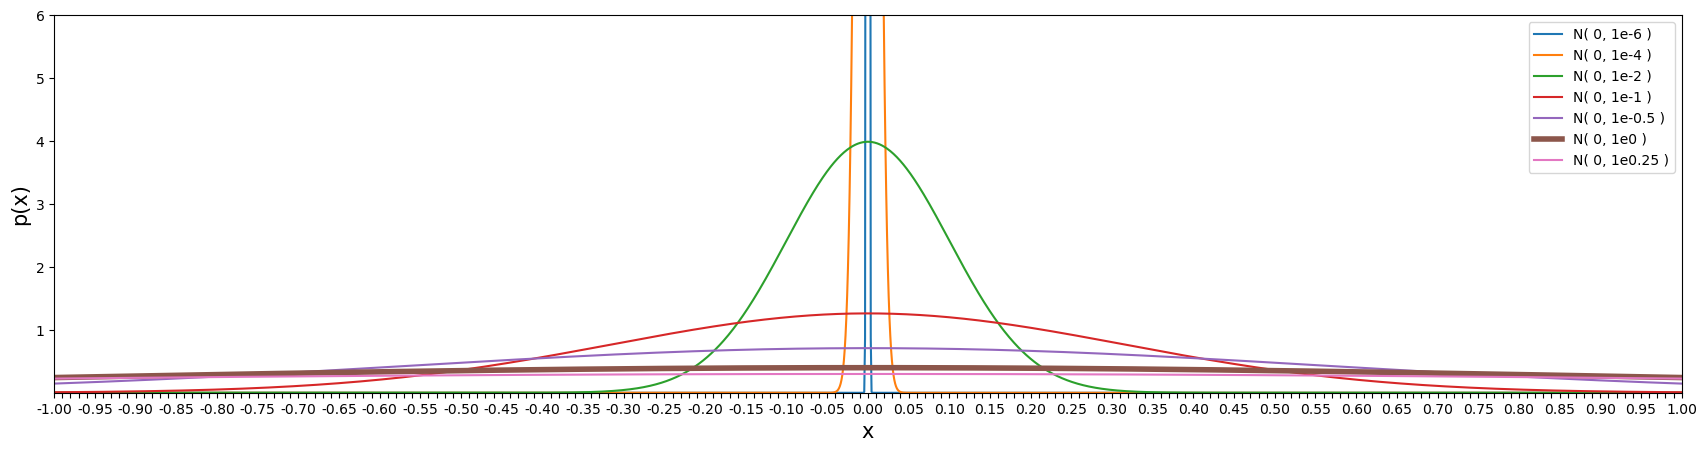

In [35]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(21, 5), squeeze=True, dpi=100)

lims = 1
z = np.linspace(-lims, lims, 2000)

ALL_LOG_VARIANCES = [-6, -4, -2, -1, -0.5, 0, 0.25]

for var in ALL_LOG_VARIANCES:
    pds = norm.pdf(z, scale=np.sqrt(10**var))
    linewidth = 4 if var == 0 else 1.5
        
    ax.plot(z, pds, '-', label=f'N( 0, 1e{var} )', linewidth=linewidth)
ax.set_ylim([0.001, 6])
ax.set_xlim([-lims, lims])
start, end = ax.get_xlim()

steps = 0.01
tick_positions = np.arange(start, end+steps, steps)
tick_lables = [f'{tick:.2f}' if i % 5 == 0 else '' for i, tick in enumerate(tick_positions)]
    
ax.set_xlabel('x', size=15)
ax.set_ylabel('p(x)', size=15)
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_lables)
ax.legend()
_=_

-----------

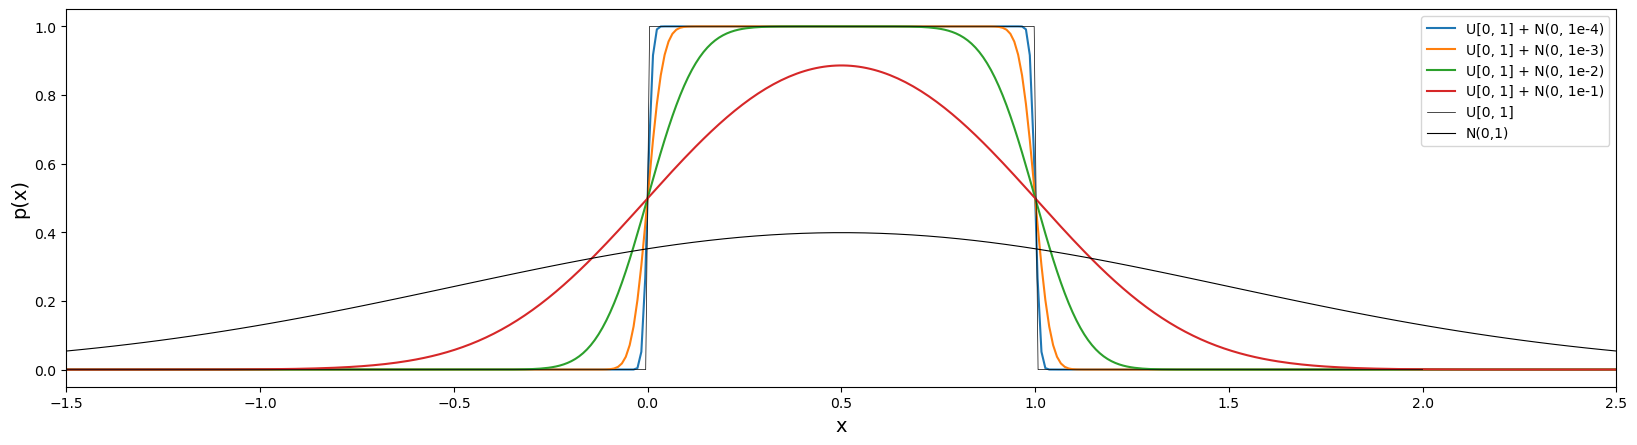

In [10]:
def plot_line_noise(ax, var, label):
    x = np.linspace(-2, 2, 400)
    ax.plot(x+0.5, pdf_N_plus_Uni(x, var), label=label)
    
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), squeeze=False, dpi=100)

#for var in [-100, -50, -10, -5, -2, -1, -0.5, -0.25, 0, 0.25]:
for var in [-4, -3, -2, -1]:
    label = f'U[0, 1] + N(0, 1e{var})'
    plot_line_noise(axs[0][0], 10**var, label)
    #plot_density_state(axs[1], 10**var, label)
x = np.linspace(-2, 2, 400)
y = np.zeros_like(x)
y[np.logical_and(x > 0, x < 1)] = 1
axs[0][0].plot(x, y, label='U[0, 1]', color='k', linewidth=0.5)

x = np.linspace(-2, 2, 100)
ax = axs[0][0]
ax.plot(x+0.5, norm.pdf(x), '-', color='k', label='N(0,1)', linewidth=0.8)
ax.set_xlim([-1.5, 2.5])

ax.legend()
ax.set_ylabel('p(x)', size=14)
ax.set_xlabel('x', size=14)

_=_
#_=fig.savefig(f'random/uniform + normal.png')

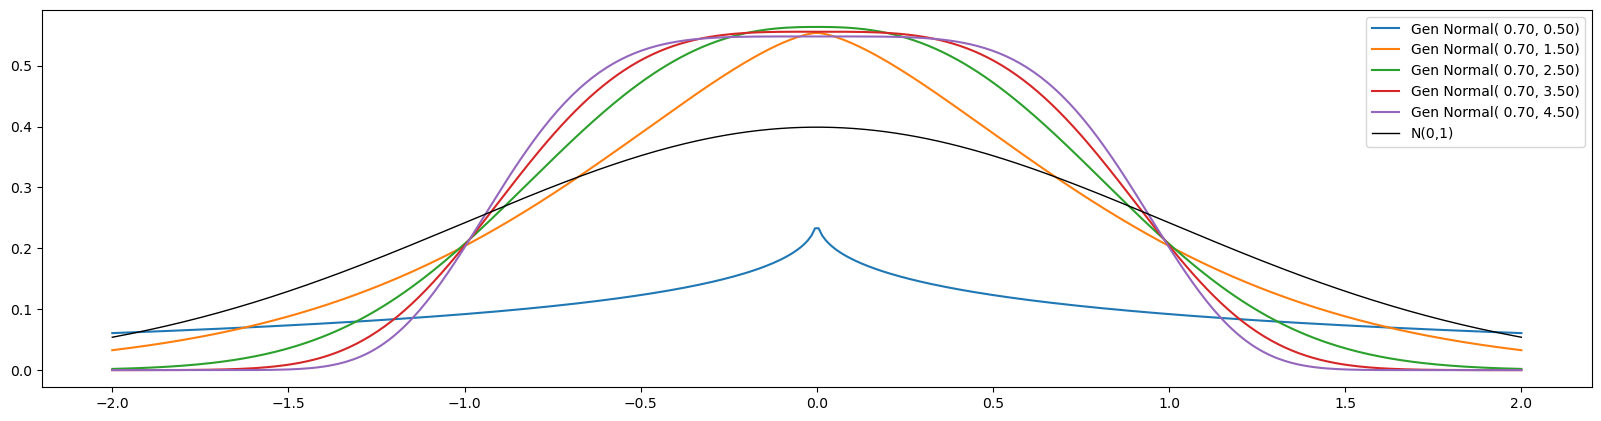

In [20]:
# Generalized Normal

def generalized_normal_log_pdf(x, alpha, beta):
    log_alpha = np.log(alpha)
    log_beta = np.log(beta)

    return log_beta - np.log(2) - log_alpha - loggamma(1 / beta) - (np.abs(x) / alpha) ** beta

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), squeeze=True, dpi=100)
x = np.linspace(-2, 2, 400)


for b in np.arange(0.5, 5, 1):
    ax.plot(x, np.exp(generalized_normal_log_pdf(x, alpha=1, beta=b)), label=f'Gen Normal( {a:.2f}, {b:.2f})')
#ax.plot(x+0.5, np.exp(generalized_normal_log_pdf(x, alpha=0.4052, beta=2)), '-', label='Gen Normal', linewidth=0.8)
#ax.plot(x+0.5, np.exp(generalized_normal_log_pdf(x, alpha=1, beta=2)), '-', label='Gen Normal', linewidth=0.8)
#ax.plot(x+0.5, np.exp(generalized_normal_log_pdf(x, alpha=0.4052, beta=2)), '-', label='Gen Normal', linewidth=0.8)
ax.plot(x, norm.pdf(x), '-', color='k', label='N(0,1)', linewidth=1)
ax.legend()

_=_

In [ ]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), squeeze=False, dpi=100)

def plot_density_state(ax, var, label):
    size = 100000
    e = norm.rvs(scale=np.sqrt(var), size=size)
    uniform_rv = uniform.rvs(size=size, loc=-0.5)
    pds = pdf_N_plus_Uni(e+uniform_rv, var)
    #pds = np.log(pds)
    #label += f' mean: {np.log(pds).mean():.2f}'
    sns.distplot(pds, ax=ax, label=label, hist=False, kde_kws={'bw_adjust': 0.1}, kde=True, bins=100) # kde_kws={'cumulative':True})

ax = axs[0][0]
for var in [-10, -5, -2, -1, -0.5, -0.25, 0, 0.25]:  # -100, -50, 
    label = f'U[0, 1] + N(0, 1e{var})'
    plot_density_state(ax, 10**var, label)

ax.axvline(1, color='k', label='U[0, 1]')
ax.set_ylabel('p( p(x) )', size=14)
ax.set_xlabel('p(x)', size=14)
ax.set_ylim(top=20)
#ax.set_xlim(left=-2.5)
ax.legend()
plt.suptitle('Density of States of Uniform + Noise', size=15)

_=_

--------------------

In [6]:
def f(z, s):
    return np.sqrt(np.pi/2) *(-erf(np.sqrt(-z - np.log(2 *np.pi* s**2)/2)) + erf(np.sqrt(1 - z - np.log(2 *np.pi *s**2)/2)))

def plot_made_up_state_density(ax, var, label):
    x = np.linspace(-2, 2, 400)
    ax.plot(x+0.5, f(x, var), label=label)
    
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), squeeze=True, dpi=100)
#ax.set_yscale('log')

for var in [ 0.1, 0.01, 0.001, 0.0001]:
    label = f'U[0, 1] + N(0, 1e{var})'
    plot_made_up_state_density(ax, 10**var, label)
    
ax.legend()

<ipython-input-6-89a28574b705>:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.pi/2) *(-erf(np.sqrt(-z - np.log(2 *np.pi* s**2)/2)) + erf(np.sqrt(1 - z - np.log(2 *np.pi *s**2)/2)))
<ipython-input-6-89a28574b705>:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.pi/2) *(-erf(np.sqrt(-z - np.log(2 *np.pi* s**2)/2)) + erf(np.sqrt(1 - z - np.log(2 *np.pi *s**2)/2)))
<ipython-input-6-89a28574b705>:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.pi/2) *(-erf(np.sqrt(-z - np.log(2 *np.pi* s**2)/2)) + erf(np.sqrt(1 - z - np.log(2 *np.pi *s**2)/2)))
<ipython-input-6-89a28574b705>:2: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(np.pi/2) *(-erf(np.sqrt(-z - np.log(2 *np.pi* s**2)/2)) + erf(np.sqrt(1 - z - np.log(2 *np.pi *s**2)/2)))


------------

KL Divergence between Normal / Prior := $q(x)$ and Uniform + Normal Noise $:= p(x)$ 

$KL(p||q) = \int p(x) \frac{p(x)}{q(x)}dx $
I can show that for multivariate distributions where p(x) = [Uniform + Normal, Normal, ...., Normal] and all normals are iid, the dimension is irrelevant, only the first dimension is relevant.<br>

We sample from $p(x)$ to get the KL divergence.

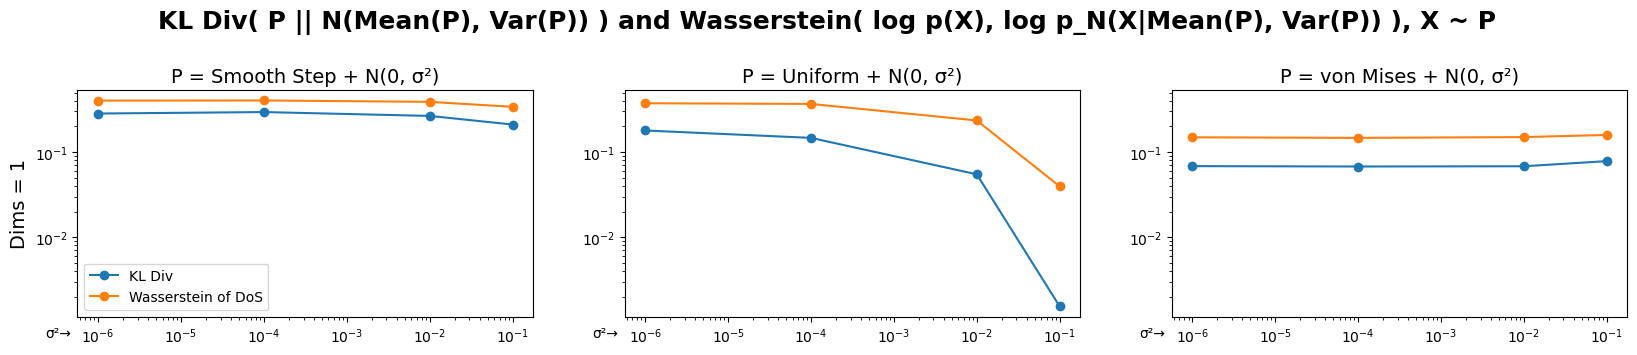

In [16]:
%matplotlib inline
def pdf_on_manifold(dist, dist_params, variance, sample_size):
    norm_scale = np.sqrt(variance)
    e = norm.rvs(scale=norm_scale, size=SAMPLE_N)
    
    if type(dist) == SmoothstepData:
        samples = e + dist.sample_on_manifold(size=sample_size)
        pdf = dist.pdf_on_manifold
    else:
        samples = e + dist.rvs(**dist_params, size=sample_size) 
        pdf = dist.pdf
    
    convolution_norm_samples = norm.rvs(scale=np.sqrt(variance), size=2000)
    #convolution_norm_samples = distribution.rvs(**dist_params, size=1000)
    
    #return [np.mean(norm.pdf(sample - convolution_norm_samples, scale=norm_scale)) for sample in samples]
    return [np.mean(pdf(sample - convolution_norm_samples, **dist_params)) for sample in samples], samples

def kl_divergence_of_std_normal_and_iso_normal(variance, dim):
    """KL( N(0, variance) || N(0, 1))
    1/2 ( trace(1^-1 * variance) - dim + ln( 1/ det(variance) ) )
    """
    trace = dim * variance
    det = - dim * np.log(variance)
    return 1/2 * ( trace - dim + det )

SAMPLE_N = 10000
#SAMPLE_N = 1000
#SAMPLE_N = 10
#variances = np.arange(-5.99, 2.02, 0.5)
variances = np.array([-6., -4., -2., -1.]) #np.arange(-5.99, 2.01, 0.5)

#additional_dims = np.array([1, 6**2, 10**2, 14**2]) - 1
additional_dims = np.array([1]) - 1

def computer_wasserstein_distance(log_densities_per_var, additional_noise_dims):
    """log_p/q_manifold are from the manifold + Noise
    we now need to add more dimensions with noise and then compute the Wasserstein Distance
    (This should be an independent offset to wasserstein(log_p_manifold, log_q_manifold), but I don't want to show this)"""
    wasserstein_distances = []
    for var, log_densities in zip(10 ** variances, log_densities_per_var):
        log_p_manifold, log_q_manifold = log_densities
        if additional_noise_dims > 0:
            norm_samples = norm.rvs(scale=np.sqrt(var), size=(len(log_p_manifold), additional_noise_dims))
            
            log_p = log_p_manifold + norm.logpdf(norm_samples, scale=np.sqrt(var)).sum(1)
            log_q = log_q_manifold + norm.logpdf(norm_samples, scale=1).sum(1)
            distance = wasserstein_distance(log_p, log_q)
        else:
            distance = wasserstein_distance(log_q_manifold, log_p_manifold)
        wasserstein_distances.append(distance)
    return wasserstein_distances


# KL divergences of additional noise dimensions
additional_kl_divs = []
for dim in additional_dims:
    additional_kl_divs.append(
        np.array([kl_divergence_of_std_normal_and_iso_normal(10 ** var, dim=dim) for var in variances]))

# print(additional_kl_divs)
fig, axs = plt.subplots(nrows=len(additional_kl_divs), ncols=3, figsize=(20, 3*len(additional_dims)), 
                        squeeze=False, dpi=100, sharey=True)

for x_idx, data_set in enumerate(['smooth_step', 'line', 'mises']):
    kl_divergences = []
    log_densities_per_var = []
    for noise in variances:
        variance = 10.0 ** noise

        if data_set == 'line':
            e = norm.rvs(scale=np.sqrt(variance), size=SAMPLE_N)
            # Uniform + Noise data
            uniform_rv = uniform.rvs(size=SAMPLE_N, **uniform_params)
            x = e + uniform_rv

            p = pdf_N_plus_Uni(x, variance)
        elif data_set == 'mises':
            p, x = pdf_on_manifold(vonmises, mises_params_05, variance, SAMPLE_N)
        else:
            step_data = SmoothstepData(**smoothstep_params, size=1)
            p, x = pdf_on_manifold(step_data, {}, variance, SAMPLE_N)

        p = np.array(p)
        if (p == 0).mean() > 0.005:
            print((p == 0).mean(), data_set, variance)
            print('Warning: too many weird samples')

        p_not_zero = p != 0
        log_p = np.log(p[p_not_zero])
        # Prior / Normal
        log_q = norm.logpdf(x[p_not_zero], scale=np.sqrt(x.var()), loc=x.mean())

        kl_divergences.append(np.mean(log_p - log_q))
        log_densities_per_var.append((log_p, log_q))

    for y_idx, additional_dim in enumerate(additional_dims):
        ax = axs[y_idx, x_idx]
        ax.set_yscale('log'), ax.set_xscale('log')
        ax.yaxis.set_tick_params(which='both', labelbottom=True)
        
        exp_var = 10**variances
        
        # KL Div
        additional_kl_div = additional_kl_divs[y_idx]
        ax.plot(exp_var, kl_divergences + additional_kl_div, 'o-', label='KL Div')

        # Wasserstein
        wasserstein_distances = computer_wasserstein_distance(log_densities_per_var, additional_noise_dims=additional_dim)
        ax.plot(exp_var, wasserstein_distances, 'o-', label='Wasserstein of DoS')
        
        ax.annotate('σ²→', xy=(-0.07, -0.04), ha='left', va='top', xycoords='axes fraction')
        
        if y_idx == 0:
            ax.set_title(f'P = {dataset_to_name(data_set)} + N(0, σ²)', size=14)
        if x_idx == 0:
            ax.set_ylabel(f'Dims = {additional_dims[y_idx]+1}', size=14)
        if x_idx == 0 and y_idx == 0:
            ax.legend()
plt.suptitle('KL Div( P || N(Mean(P), Var(P)) ) and Wasserstein( log p(X), log p_N(X|Mean(P), Var(P)) ), X ~ P', size=18, y=1.15, fontweight='bold')
_=_

-----------
# Central Limit Theorem

In [ ]:
N = 100
scale = 1e-20

def sampler(dim):
    samples = norm.rvs(scale=scale, size=(dim, N))
    samples = np.double(samples)
    
    log_pdf_single = norm.logpdf(samples, scale=scale)
    log_pdf = log_pdf_single.sum(0)
    
    z_n = (log_pdf - log_pdf.mean()) / np.sqrt(log_pdf.var())

    sns.distplot(z_n, label=dim, hist=False)

sampler(dim=1000)
sampler(dim=2000)
sampler(dim=5000)
#sampler(dim=1000)

z = np.linspace(-6, 6, 1000)
pds = norm.pdf(z)
plt.plot(z, pds, '-', color='r', label='N(0, 1)')

plt.legend()

In [ ]:


def sampler_2(dim, variance):
    scale = np.sqrt(variance)
    samples = norm.rvs(scale=scale, size=(dim, N))
    samples = np.double(samples)
    
    log_pdf_single = norm.logpdf(samples, scale=scale)
    log_pdf = log_pdf_single.sum(0)
    
    z_n = log_pdf / dim
    #print(z_n.mean())
    #print(np.log(1 / scale))
    #print('---')

    #z_n -= z_n.mean()
    sns.distplot(z_n, label=f'var = {variance}', hist=False, kde_kws={'bw_adjust': 0.1})

fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(20, 5), squeeze=True, dpi=100)
N = 10000
Dim = 1
sampler_2(dim=Dim, variance=1e-4)
sampler_2(dim=Dim, variance=1e-2)
sampler_2(dim=Dim, variance=1e-1)
sampler_2(dim=Dim, variance=1)

plt.legend()
_=_

In [ ]:
def normal_state_dens_plotter(var):
    x = np.linspace(-6, 3, 100)
    density = 2*var * chi2.pdf(df=1, x=-(2 * var * x + var*np.log(2 * np.pi*var)))
    plt.plot(x, density, '-', label=f'N(0, {var:.1e})')

normal_state_dens_plotter(1)
normal_state_dens_plotter(0.1)
normal_state_dens_plotter(0.01)

plt.legend()
_=_

------------
# Predicted Volume Change
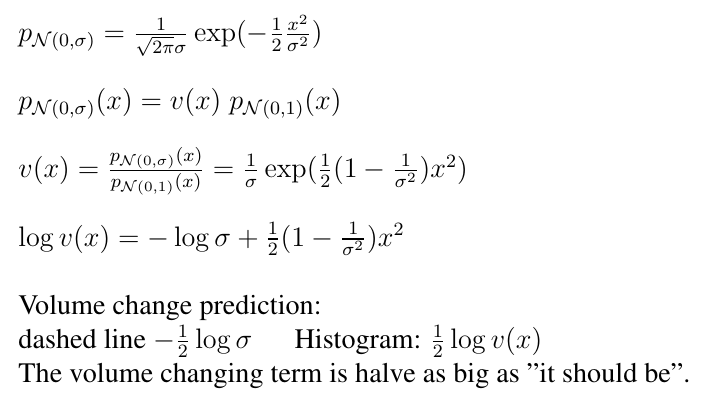

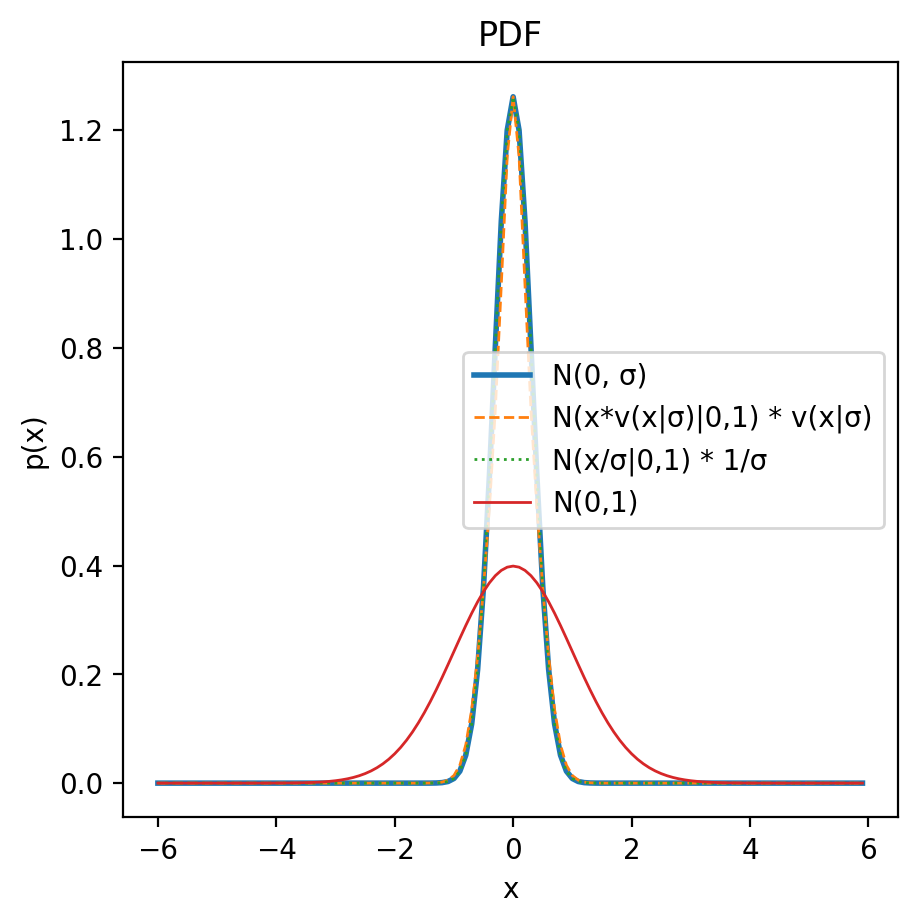

In [11]:
SAMPLE_N = 1000
#samples = norm.rvs(scale=np.sqrt(var), size=(SAMPLE_N))
var = 1e-1
x = np.arange(-6, 6, 0.1)
true_pd = norm.pdf(x, scale=np.sqrt(var))

def volume_change_prediction(x, var):
    return 1/np.sqrt(var) * np.exp(1/2 * (1 - 1/var) * x**2)

volume_change = volume_change_prediction(x, var)
predicted_pd = norm.pdf(x*volume_change) * volume_change
static_prediction = norm.pdf(x*1/np.sqrt(var)) * 1/np.sqrt(var)

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5), squeeze=True, dpi=200)

ax.plot(x, true_pd, label='N(0, σ)', linewidth=2)
ax.plot(x, predicted_pd, label='N(x*v(x|σ)|0,1) * v(x|σ)', linewidth=1, linestyle='--')
ax.plot(x, static_prediction, label='N(x/σ|0,1) * 1/σ', linewidth=1, linestyle='dotted')
ax.plot(x, norm.pdf(x), label='N(0,1)', linewidth=1)


ax.legend()
ax.set_xlabel('x')
ax.set_ylabel('p(x)')
ax.set_title('PDF')
_=_

-----------
# Mises in High Dim

In [ ]:
target_dim_width = 6
rotation_matrix = special_ortho_group.rvs(target_dim_width**2)
def create_high_dim_mises(sample_count):
    
    images = []
    for _ in range(sample_count):
        x_1 = vonmises.rvs(kappa=6)
        x_2 = target_dim_width* np.cos(x_1), target_dim_width* np.sin(x_1)
        
        flat_embedding = np.zeros(target_dim_width**2)
        flat_embedding[0:2] = x_2

        # orthogonal matirx => side irrelevant
        rotated_embedding = rotation_matrix @ flat_embedding
        image = rotated_embedding.reshape((target_dim_width, target_dim_width))
        images.append(image)
        
    return images

sample_count = 18
images = create_high_dim_mises(sample_count)

fig, axs = plt.subplots(nrows=3, ncols=6, squeeze=False, figsize=(30, 10))
axs = axs.flatten()
for img, ax in zip(images, axs):
    ax.matshow(img, cmap='gray')
    ax.set_xticks([]), ax.set_yticks([])

--------
## Smooth Step Works

In [ ]:
step_data = SmoothstepData(**smoothstep_params, train_size=10)
data = step_data._sample_on_manifold(size=100000)
sns.distplot(data, hist=False, norm_hist=True, kde_kws={'bw_adjust': 0.8}, kde=True)

------------
Variance of Noise Dimensions

In [ ]:
#mises_params_05 = {'kappa': 0.5}
#uniform_params = {'loc': -0.5, 'scale': 1}
smoothstep_params = dict(dimension=36, start=-5, end=5, offset=1, Range=10, growth=0.5)


def get_dataset(var, dimension):
    kwargs = {'noise_scale': np.sqrt(var), 'sample_seed': 42, 'train_size': 1000, 'dimension': dimension}
    #data = SmoothstepData(start=smoothstep_params['start'], end=smoothstep_params['end'], offset=smoothstep_params['offset'],
    #                          Range=smoothstep_params['Range'], growth=smoothstep_params['growth'], **kwargs)
    #data = LineData(line_length=uniform_params['scale'], **kwargs)
    data = VonMises(sphere_radius=0, mises_kappa=mises_params_05['kappa'], **kwargs)
    return data
    
for total_dim in [2, 10, 36, 100]:
    print('----------------------')
    print(f'Total Dimensions: {total_dim} Noise Dimensions: {total_dim-1}\n')
    for var in [1e-100, 1e-30, 1e-6, 1e-4, 1e0, 2]:
        dataset = get_dataset(var, total_dim)
        #manifold_pd = dataset.train_data[MANIFOLD_LOG_PD]
        inflated_manifold_pd = dataset.train_data[INFLATED_MANIFOLD_LOG_PD]

        scale = np.double(np.sqrt(var))
        samples = norm.rvs(scale=scale, size=(100000, total_dim-1))
        noise_pd = norm.logpdf(samples, scale=scale).sum(1)

        if var < 1:
            var = f'1e{np.log10(var)}'
        print(f'σ²={var}\t| Mani Mean = {inflated_manifold_pd.mean():.2f} Var = {inflated_manifold_pd.var():.5f} | Noise Dimensions ' +
             f'Mean = {noise_pd.mean():.2f} Var = {noise_pd.var():.2f}') # Avg Abs Deviation = {np.mean( np.abs(noise_pd - noise_pd.mean()) ):.2f}')

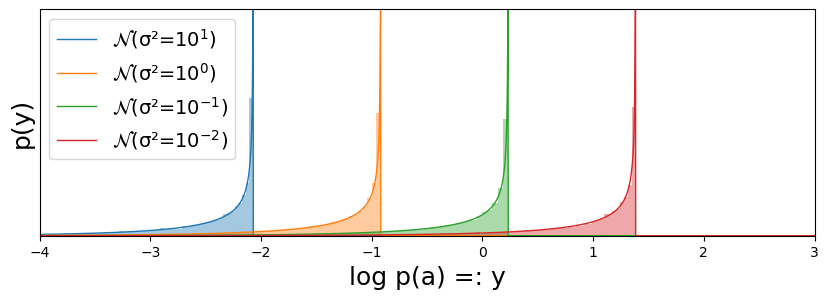

In [38]:
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 3), squeeze=True, dpi=100)

x = np.linspace(-5, 6.5, 10000)

#for i, var in enumerate([1e-6, 1e-5, 1, 10]):
for i, var in enumerate([10, 1, 1e-1, 1e-2]):
    color = sns.color_palette("tab10")[i]
    var = np.double(var)
    scale = np.sqrt(var)
    
    samples = norm.rvs(scale=scale, size=10000)
    pd = norm.logpdf(samples, scale=scale)
    sns.distplot(pd, color=color, bins=200, kde=False, ax=ax, norm_hist=True)
    
    t = - ( 2 * x + np.log(2 * np.pi * var))
    
    # around 0 chi2 is infinity
    #not_close_to_0 = np.logical_or(t < -0.2, t > 0.2)
    #t = t[not_close_to_0]
    #x = x[not_close_to_0]
    
    density = chi2.pdf(df=1, x=t) * 2
    
    max_val = 10
    density[density > max_val] = max_val
    
    #ax.plot(x, density, label=f'N(σ²={var:.1e})', linewidth=1, color=color)
    ax.plot(x, density, label=f'{gauss_symbol()}(σ²={var_to_label(var)})', linewidth=1, color=color)
    
#handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc=(0.7, 0.85))
#fig.legend(handles, labels, loc='center right')

ax.legend(fontsize=LEGEND_SIZE)
ax.set_xlim([-4, 3])
ax.set_ylim(top=max_val)
ax.set_xlabel('log p(a) =: y', size=AXIS_TITLE_SIZE)
ax.set_ylabel('p(y)', size=AXIS_TITLE_SIZE)
ax.set_yticks([])
#ax.set_title('Density of States of different Normal Distributions')
plt.savefig('E:/dos_gauss_proof.pdf', format='pdf', bbox_inches='tight')
_=_

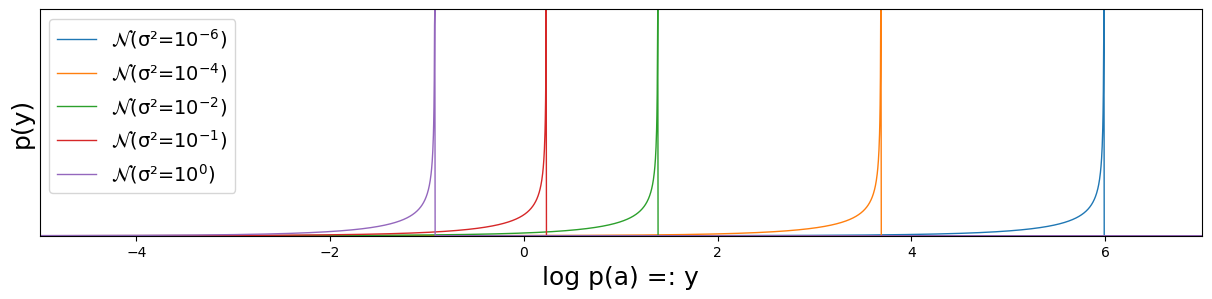

In [32]:
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(15, 3), squeeze=True, dpi=100)

x = np.linspace(-15, 15, 10000)

#for i, log_var in enumerate([-4, -2, -1, 0, 1, 2, 4]):
#for i, log_var in enumerate([-10, -5, -2, -1, 0, 1, 2, 5, 10]):
for i, log_var in enumerate([-6, -4, -2, -1, 0]):
    var = 10**log_var
    color = sns.color_palette("tab10")[i]
    var = np.double(var)
    scale = np.sqrt(var)
    
    samples = norm.rvs(scale=scale, size=10000)
    pd = norm.logpdf(samples, scale=scale)
    #sns.distplot(pd, color=color, bins=500, kde=False, ax=ax, norm_hist=True)
    
    t = - ( 2 * x + np.log(2 * np.pi * var))
    
    # around 0 chi2 is infinity
    #not_close_to_0 = np.logical_or(t < -0.2, t > 0.2)
    #t = t[not_close_to_0]
    #x = x[not_close_to_0]
    
    density = chi2.pdf(df=1, x=t) * 2
    
    max_val = 10
    density[density > max_val] = max_val
    
    log_var = int(np.log10(var))
    ax.plot(x, density, label=f'{gauss_symbol()}(σ²={var_to_label(var)})', linewidth=1, color=color)
    
#handles, labels = ax.get_legend_handles_labels()
#fig.legend(handles, labels, loc=(0.7, 0.85))
#fig.legend(handles, labels, loc='center right')

ax.legend(fontsize=14)
ax.set_xlim([-5, 7])
ax.set_ylim(bottom=0)
ax.set_ylim(top=max_val)
ax.set_xlabel('log p(a) =: y', size=18) #  ||||||| y ∈ supp( log f(A) ) or y = log f(a)?
ax.set_ylabel('p(y)', size=18)
ax.set_yticks([])
#ax.set_title('Density of States of different Normal Distributions')
plt.savefig('E:/dos_gauss.pdf', format='pdf', bbox_inches='tight')
_=_

In [ ]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 3), squeeze=True, dpi=100)

x = np.linspace(-5, 70, 10000)

max_vals = []
for var in range(-50, 1, 10):
    var = 10**var
    #print(np.log10(var), -np.log(2 * np.pi*var)/2)
    t = - ( 2 * x + np.log(2 * np.pi * var))
    
    # around 0 chi2 is infinity
    not_close_to_0 = np.logical_or(t < -0.2, t > 0.2)
    t = t[not_close_to_0]
    x = x[not_close_to_0]
    
    density = chi2.pdf(df=1, x=t) * 2
    
    #x += np.log(2 * np.pi * var) / 2
    
    # this is the minimal maximum value of all of them. 
    # I know this is hacky but the degeneratedness of chi2 is annoying
    max_val = 1.5677022662412656
    density[density > max_val] = max_val
    
    max_vals.append(density.max())
    ax.plot(x, density, label=f'σ² = {var:.1e}', linewidth=1)

ax.set_xlabel('log p(x) := y', size=13)
ax.set_ylabel('p(y)', size=13)
ax.set_yticks([])
ax.legend()
ax.set_xlim(right=60)
ax.set_ylim(top=max_val)
ax.set_title('Density of States of different Gaussians')
print('Note chi^2 df=1 goes to infinity at position 0')
_=_

Note chi^2 df=1 goes to infinity at position 0


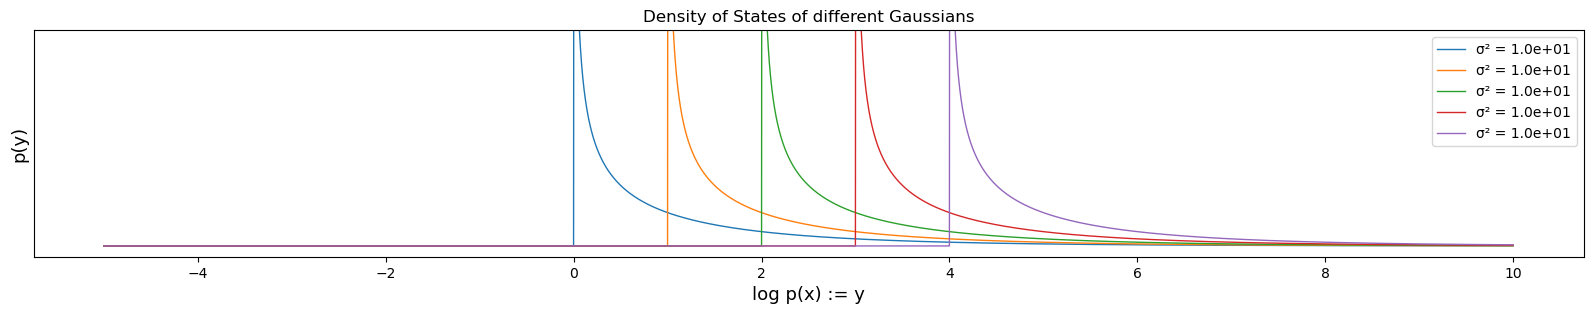

In [14]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 3), squeeze=True, dpi=100)

x = np.linspace(-5, 10, 10000)

max_vals = []
for o in range(5):
    
    #print(np.log10(var), -np.log(2 * np.pi*var)/2)
    t = x - o
    
    density = chi2.pdf(df=1, x=t)
    
    #x += np.log(2 * np.pi * var) / 2
    
    # this is the minimal maximum value of all of them. 
    # I know this is hacky but the degeneratedness of chi2 is annoying
    max_val = 1.5677022662412656
    density[density > max_val] = max_val
    
    max_vals.append(density.max())
    ax.plot(x, density, label=f'σ² = {var:.1e}', linewidth=1)

ax.set_xlabel('log p(x) := y', size=13)
ax.set_ylabel('p(y)', size=13)
ax.set_yticks([])
ax.legend()
#ax.set_xlim(right=60)
ax.set_ylim(top=max_val)
ax.set_title('Density of States of different Gaussians')
print('Note chi^2 df=1 goes to infinity at position 0')
_=_

-------------
Density of State Distance

Using 200000 samples


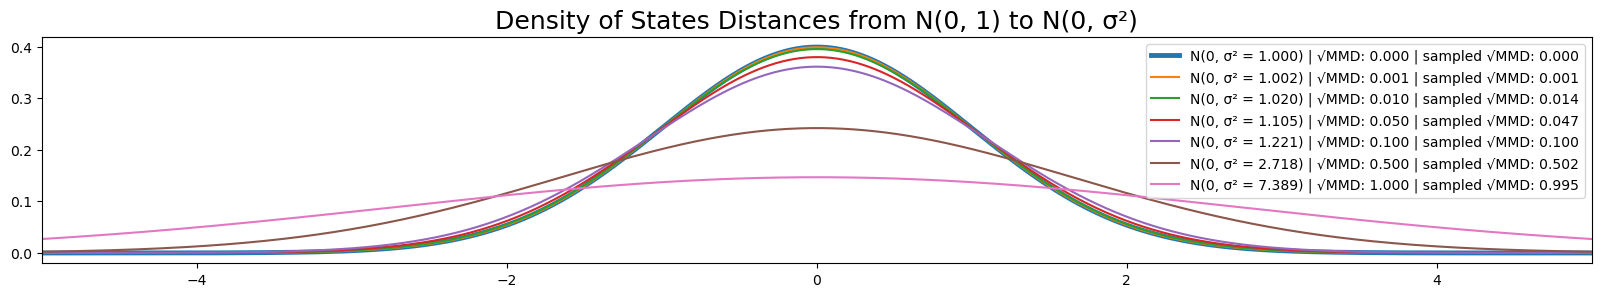

In [14]:
%matplotlib inline
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 3), squeeze=True, dpi=100)

x = np.linspace(-5, 5, 1000)
sample_size = 200000
print(f'Using {sample_size} samples')
def plot_normal_dist(distance):
    scale = np.double(np.sqrt(np.exp(2*distance)))
    density = norm.pdf(x, scale=scale)
    
    one_scale = np.double(1)
    std_ld = norm.logpdf(norm.rvs(scale=one_scale, size=sample_size), scale=one_scale)
    variational_ld = norm.logpdf(norm.rvs(scale=scale, size=sample_size), scale=scale)
    
    sampled_dist = np.abs(variational_ld.mean() - std_ld.mean())
    linewidth = 3.5 if distance == 0 else None
    ax.plot(x, density, label=f'N(0, σ² = {scale**2:.3f}) | √MMD: {distance:.3f} | sampled √MMD: {sampled_dist:.3f}', linewidth=linewidth)
    

plot_normal_dist(0)
plot_normal_dist(0.001)
plot_normal_dist(0.01)
plot_normal_dist(0.05)
plot_normal_dist(0.1)
plot_normal_dist(0.5)
plot_normal_dist(1)

ax.legend()

ax.set_title('Density of States Distances from N(0, 1) to N(0, σ²)', size=18)
ax.set_xlim([-5, 5])
_=_

-------
# Fluctuation of Wasserstein between the same distribution

In [8]:
size = 2**13
scale = 1
dim = 2

def approx_distances(dim):
    distances_wasser, distances_mmd = [], []
    for _ in range(20):
        states_1 = norm.logpdf(norm.rvs(scale=scale, size=(size, dim)), scale=scale).sum(1) / dim
        states_2 = norm.logpdf(norm.rvs(scale=scale, size=(size, dim)), scale=scale).sum(1) / dim

        distance_wasser = wasserstein_distance(states_1, states_2)
        distance_mmd = np.abs(states_1.mean() - states_2.mean())
        
        distances_wasser.append(distance_wasser)
        distances_mmd.append(distance_mmd)
        
    return distances_wasser, distances_mmd
    
print('Distances between sampled normal distribution DoS')
print('Mean, Variance')
for dim in [1, 2, 36, 100, 196]:
    distances_wasser, distances_mmd = approx_distances(dim)
    print(f'Dim: {dim}')
    print(f'Wasser: {np.mean(distances_wasser):.4f}, {np.var(distances_wasser):.4f}')
    print(f'MMD: {np.mean(distances_mmd):.4f}, {np.var(distances_mmd):.4f}')
    print('----')

Distances between sampled normal distribution DoS
Mean, Variance
Dim: 1
Wasser: 0.0126, 0.0000
MMD: 0.0078, 0.0000
----
Dim: 2
Wasser: 0.0102, 0.0000
MMD: 0.0070, 0.0000
----
Dim: 36
Wasser: 0.0027, 0.0000
MMD: 0.0017, 0.0000
----
Dim: 100
Wasser: 0.0014, 0.0000
MMD: 0.0008, 0.0000
----
Dim: 196
Wasser: 0.0009, 0.0000
MMD: 0.0006, 0.0000
----


In [12]:
N = 1000000

log_pdf = norm.logpdf(norm.rvs(size=N))
log_pdf = log_pdf - log_pdf.mean()

print((np.abs(log_pdf) ** 3).mean())

1.0875132244461676


In [9]:
sigma = 1
smpls = norm.rvs(size=5000)
neg_entro = norm.logpdf(smpls, scale=sigma).mean()
print(neg_entro)

print('true entro', 1/2 * np.log(2 * np.pi * sigma) + 1/2)

-1.4167505819845994
true entro 1.4189385332046727


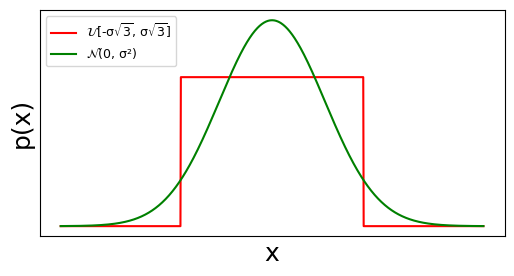

In [44]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 3), squeeze=True, dpi=100)

x = np.linspace(-4, 4, 1000)

ax.plot(x, uniform.pdf(x, loc=-np.sqrt(3), scale=2*np.sqrt(3)), label='$\mathcal{U}$[-σ$\sqrt{3}$, σ$\sqrt{3}$]', color='r')
ax.plot(x, norm.pdf(x), label=f'{gauss_symbol()}(0, σ²)', color='g')
ax.set_yticks([])
ax.set_xticks([])
ax.set_ylabel('p(x)', size=AXIS_TITLE_SIZE)
ax.set_xlabel('x', size=AXIS_TITLE_SIZE)
    
ax.legend(fontsize=LEGEND_SIZE-5, loc='upper left')

plt.savefig('E:/normal_and_uniform.pdf', format='pdf', bbox_inches='tight')

In [51]:
import torch
from torch import nn
from torch.distributions.multivariate_normal import MultivariateNormal
import numpy as np

from warnings import warn

# Master addition
from master.config import DEVICE
from easy_access import EasyAccess
from torch import distributions
from flow_ssl.realnvp.coupling_layer import Rescale
from flow_ssl.realnvp.scale_layer import ScaleLayer


def to_normal(X):
    return float(X.detach().cpu())


class TwoDNet(nn.Module):

    def __init__(self, coupling_layer_count, nice_or_realnvp, args):
        """coupling_layer_count (will NOT be multiplied by 2)"""
        super(TwoDNet, self).__init__()

        self._log_det = None
        self.prior = MultivariateNormal(torch.zeros(2, dtype=torch.float).cuda(),
                                        torch.eye(2, dtype=torch.float).cuda())
        self.nice_implementation = nice_or_realnvp == 'NICE'

        st_nets = []
        rescalings = []
        for _ in range(coupling_layer_count):
            std_dev = 0.5 if self.nice_implementation else 0.1
            l1 = nn.Linear(1, 16)
            l1.weight = torch.nn.init.normal_(l1.weight, mean=0.0, std=std_dev)

            l2 = nn.Linear(16, 16)
            l2.weight = torch.nn.init.normal_(l2.weight, mean=0.0, std=std_dev)

            l3 = nn.Linear(16, 2)
            l3.weight = torch.nn.init.normal_(l3.weight, mean=0.0, std=std_dev)

            st_net = nn.Sequential(
                    #nn.Linear(1, 2))
                    l1,
                    nn.ReLU(),
                    l2,
                    nn.ReLU(),
                    l3
                )
            st_nets.append(st_net)
            # Learnable scale for s / adapted from original code
            rescalings.append(Rescale(1, one_dimensional=True))

        self.store_for_fullys = nn.Sequential(*st_nets)
        self.store_for_resacles = nn.Sequential(*rescalings)

        self.st_nets = st_nets
        self.rescalings = rescalings
        self.new_loss = 'new_loss' in dir(args) and args.new_loss

    def forward(self, batch: torch.Tensor) -> torch.Tensor:
        X = batch[..., 0].squeeze(1)
        Y = batch[..., 1].squeeze(1)
        log_det = torch.zeros(len(batch)).cuda()
        for i, (st_net, rescaling) in enumerate(zip(self.st_nets, self.rescalings)):
            st = st_net(X)
            Y = Y.squeeze(1)

            s = st[..., 0]
            t = st[..., 1]

            if self.nice_implementation:
                Y = Y + t
            else:  # RealNVP
                # adapted from original code
                s = rescaling(torch.tanh(s))
                Y = (Y + t) * s.exp()
                log_det += s

            Y = Y.unsqueeze(1)

            # swap
            tmp = Y
            Y = X
            X = tmp

        # stack invertetly
        batch = torch.stack((Y, X), axis=2)
        
        self._log_det = log_det
        return batch


In [54]:
from PIL import Image
from numpy import asarray
import torch
import itertools


# load the image
image = Image.open('C:/Mega/trunk/master-document/thesis/intro/img/org.png')
# convert image to numpy array
data = asarray(image)
shape = data.shape

print('normal shape ', shape)
#print(data)

NICE = False
for i in range(200):
    #print(i)
    
    if NICE:
        nf = TwoDNet(10, nice_or_realnvp='NICE', args=None).cuda()
    else:
        nf = TwoDNet(10, nice_or_realnvp='RealNVP', args=None).cuda()

    #checkpoint = torch.load('F:/master_data/checkpoints/inflation-04.04_11-55-40-smooth_step-exp/NICE_2d_smooth_step/dim2_var1e-2.0/check/checkpoint.pt')
    #nf.load_state_dict(checkpoint['model'])

    coordinates = np.array(list(itertools.product(np.arange(0, shape[0]-1, .5), np.arange(0, shape[1]-1, .5))))
    #print(coordinates.shape)

    #torch.Size([32, 1, 1, 2])

    coor = torch.from_numpy(coordinates).float()

    """xdim = coor[:, 0]
    ydim = coor[:, 1]
    
    xmax, ymax = xdim.max(), ydim.max()
    
    xdim = (xdim / xdim.max()) * 10 - 5
    
    ydim = (ydim / ydim.max()) * 2 - 1
    
    coor[:, 1] = ydim
    coor[:, 0] = xdim
    """
    expanded = coor.unsqueeze(1).unsqueeze(1)
    expanded = expanded.cuda()

    res = nf(expanded)


    res = res.squeeze(1).cpu().int()

    """xdim = res[:, 0]
    xdim = (xdim + 5) / 10 * xmax
    
    ydim = res[:, 1]
    ydim = (ydim + 1) / 2 * ymax
    
    res[:, 1] = ydim
    res[:, 0] = xdim
    """
    res = res.numpy()

    res[:, 0] = res[:, 0] - res[:, 0].min()
    res[:, 1] = res[:, 1] - res[:, 1].min()

    #res = res * 10

    if res[:, 0].max() > 1000 or res[:, 1].max() > 1000: continue
    
    new_img = np.zeros((res[:, 0].max() + 1, res[:, 1].max() + 1, 3), dtype=np.uint8)
    #print('new shape', new_img.shape)
    coordinates = np.round(coordinates).astype(int)

    res = res.round()
    new_img[res[:, 0], res[:, 1]] = data[coordinates[:, 0], coordinates[:, 1]]
    a = Image.fromarray(new_img)
    if NICE:
        a.save(f'C:/Mega/trunk/master-document/thesis/intro/img/vp/{i}.png')
    else:
        a.save(f'C:/Mega/trunk/master-document/thesis/intro/img/nvp/sampled/{i}.png')
    a.close()

normal shape  (192, 340, 3)


SyntaxError: 'return' outside function (<ipython-input-54-dd11048e2de7>, line 15)

['INVALID', 'INVALID_AFFINE', 'INVALID_NON_AFFINE', '__array__', '__class__', '__copy__', '__deepcopy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_gid', '_ignore', '_invalid', '_invalidate_internal', '_minpos', '_parents', '_points', '_points_orig', '_shorthand_name', 'anchored', 'bounds', 'coefs', 'contains', 'containsx', 'containsy', 'corners', 'count_contains', 'count_overlaps', 'expanded', 'extents', 'from_bounds', 'from_extents', 'frozen', 'fully_contains', 'fully_containsx', 'fully_containsy', 'fully_overlaps', 'get_points', 'height', 'ignore', 'intersection', 'intervalx', 'intervaly', 'invalidate', 'inverse_transformed', 'is_affine', 'is_bbox', 'is_unit', 'max'

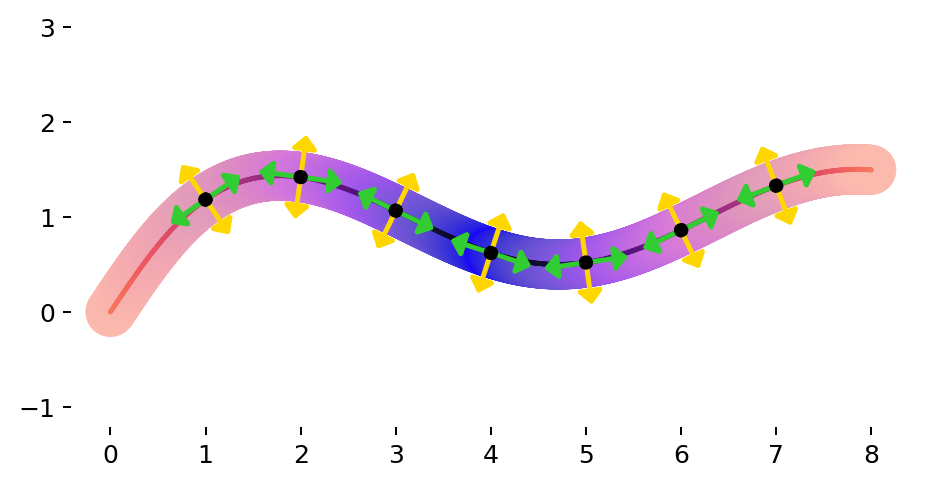

In [191]:
# import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import colorsys


def arrow_at(ax, x, length=.7, anchor_only=False):
    anchor = np.array((x, manifold(x)))
    if not anchor_only:    
        arrow_styles = dict(mutation_scale=2, linewidth=2, 
                            arrowstyle='<|-|>,head_width=2,head_length=2.1')

        anchor = np.array((x, manifold(x)))
        move = np.array((length, length * mani_grad(x)))

        # perpendicular arrow
        s = anchor - 0.5 * move
        e = s + move

        arrow = mpatches.FancyArrowPatch(*shrink_vector_to(e, s, length), color='limegreen', **arrow_styles)
        ax.add_patch(arrow)

        # rotation 
        rot_matrix = np.array(((0, 1), (-1, 0)))  
        move_rot = rot_matrix @ move

        # normal arrow
        s_rot = anchor - 0.5 * move_rot
        e_rot = s_rot + move_rot

        arrow = mpatches.FancyArrowPatch(*shrink_vector_to(s_rot, e_rot, length), color='gold', **arrow_styles)
        ax.add_patch(arrow)
    
    circle = plt.Circle(anchor, radius=.075, color='black', fill=True, alpha=1, linewidth=0)
    ax.add_patch(circle)
    
    #ax.scatter(, s=1, c='black')
    
    
def shrink_vector_to(vs, ve, length):
    calc_norm = np.linalg.norm
    v = ve - vs
    len_v = calc_norm(v)
    
    diff_to_should_length = length - len_v
    
    diff_compensator = v * 1/len_v * diff_to_should_length / 2
    
    vs = vs - diff_compensator
    ve = ve + diff_compensator
    
    return vs, ve

    
def get_ligher_colormap():    
    # Choose colormap
    cmap = plt.cm.magma

    # Get the colormap colors
    lighter = cmap(np.arange(cmap.N))

    for i, c in enumerate(lighter):
        c = colorsys.rgb_to_hls(*c[0:3])
        lighter[i][0:3] = colorsys.hls_to_rgb(c[0], 1 - 0.5 * (1 - c[1]), c[2])

    # Create new colormap
    lighter = ListedColormap(lighter)

    return lighter


def draw_inflation_draft():
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 3), squeeze=True, dpi=180)
    ax.axis('equal')
    #ax.set_yticks([])
    #ax.set_xticks([])

    for spine in ax.spines.values():
        spine.set_edgecolor('white')

    x = get_linespace()

    vmax = np.max(x) * 0.7
    vmin = np.min(x) * 1.2
    
    c = np.abs(x - np.max(x)/2)
    
    # manifold
    ax.scatter(x, manifold(x), c=c, s=1, cmap='magma', vmax=vmax, vmin=vmin)
    for a in range(int(x.min()), int(x.max())):
        if a == 0: continue
        arrow_at(ax, a, length=1, anchor_only=True)
    
    plt.savefig('E:/manifold.pdf', format='pdf', bbox_inches='tight')
    
    # inflation
    ax.scatter(x, manifold(x), c=c, s=400, linewidths=0, cmap=get_ligher_colormap(), vmax=vmax, vmin=vmin)
    
    # manifold
    ax.scatter(x, manifold(x), c=c, s=1, cmap='magma', vmax=vmax, vmin=vmin)

    for a in range(int(x.min()), int(x.max())):
        if a == 0: continue
        arrow_at(ax, a, length=1)
    
    extent = ax.get_window_extent().transformed(fig.dpi_scale_trans.inverted())
    print(dir(extent))
    fig.savefig('E:/test.png', bbox_inches=extent)

    plt.savefig('E:/inflated_manifold.pdf', format='pdf', bbox_inches='tight')
        

def manifold(x):
    return 0.5*np.sin(x) + np.tanh(x)


def mani_grad(x):
    return 0.5 * np.cos(x) + (1/np.cosh(x))**2


def get_linespace():
    return np.linspace(0, 8, 1000)

draw_inflation_draft()

#plt.savefig('E:/normal_and_uniform.pdf', format='pdf', bbox_inches='tight')

In [23]:
def sort_this(A):
    n = len(A)
    alle_i = list(range(1, n))
    alle_i.reverse()
    print(alle_i)
    print('los gehts')
    for i in alle_i:
        for j in range(1, i+1):
            if A[j-1] >= A[j]:
                # tauschen
                tmp = A[j-1]
                A[j-1] = A[j]
                A[j] = tmp
            print(A)
        print('----')
        
#sort_this([8,0,1,4,6])
#sort_this(list('WOMBAT'))
#sort_this([6,5,4,3,2])

<ipython-input-138-f3837a97deea>:18: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  vec_to_rotate = np.array([0, 1-normal_sub])


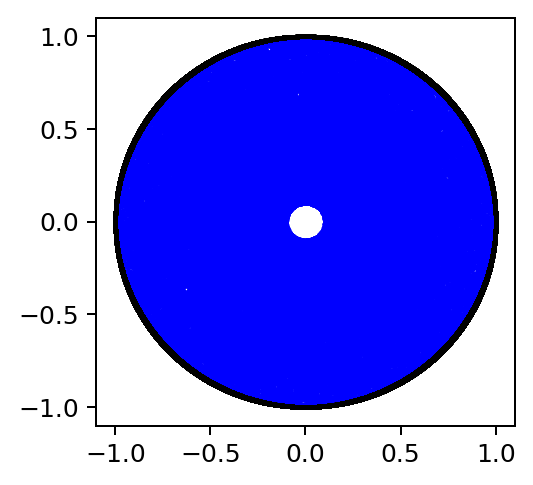

In [138]:
%matplotlib inline
import pandas as pd

unit_vector = np.array([0, 1])

samples = []
circle = []
for _ in range(100000):
    alpha = uniform.rvs(size=1) * 2 * np.pi
    rot_matrix = np.array([[np.cos(alpha), np.sin(alpha)], [-np.sin(alpha), np.cos(alpha)] ])
    
    #normal_sub = (uniform.rvs(size=1, loc=0, scale=0.5))
    normal_sub = (uniform.rvs(size=1, loc=0, scale=0.9))
    normal = rot_matrix @ normal_sub
    circle_vec = unit_vector @ rot_matrix
    
    #x = circle_vec - normal
    vec_to_rotate = np.array([0, 1-normal_sub])
    x = vec_to_rotate @ rot_matrix
    samples.append(x)
    circle.append(circle_vec)
    

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), squeeze=True, dpi=180)
samples = np.array(samples).astype(float)
circle = np.array(circle).astype(float)

ax.scatter(samples[:,0], samples[:, 1], s=.5, c='b')
ax.scatter(circle[:,0], circle[:, 1], s=1, c='k')

df = pd.DataFrame({'x': list(samples[:,0].ravel()), 'y': samples[:,1].ravel()})
#sns.displot(df,  x='x', y='y', kind="kde", fill=True)
#sns.displot(df,  x='x', y='y')

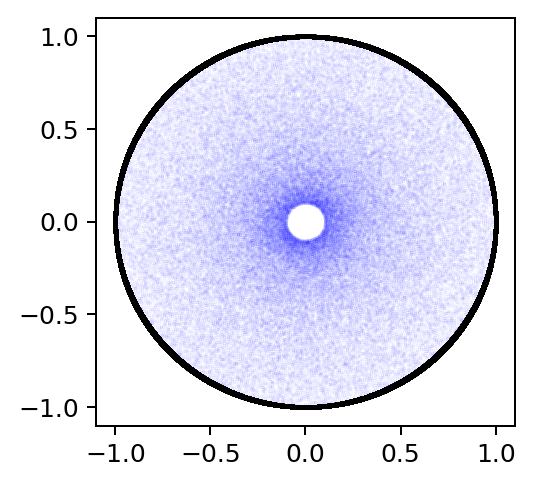

In [139]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(3, 3), squeeze=True, dpi=180)
ax.scatter(samples[:,0], samples[:, 1], s=.0001, c='b')
ax.scatter(circle[:,0], circle[:, 1], s=1, c='k')

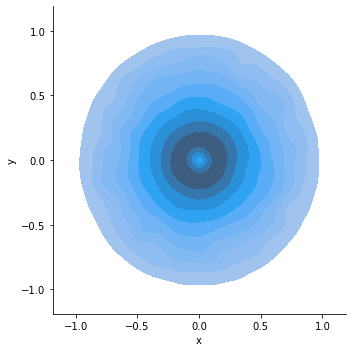

In [140]:
sns.displot(df,  x='x', y='y', kind="kde", fill=True)
#sns.displot(df,  x='x', y='y')

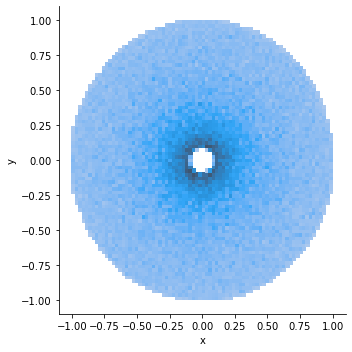

In [141]:
sns.displot(df,  x='x', y='y')

In [127]:
#sns.distplot(samples[:,1], kde_kws={'bw_adjust': 0.01})
#sns.heatmap(samples.squeeze(2))
#samples.squeeze(2).shape
#sns.heatmap(df)